In [21]:
# lidar crest data audit

# Visual sense check of station spacing - ive chosen 5 m as a sensible value without any sensitivity test or tuning yet
# ive chose transect width to be 25 m
# crest search band is plus or minus 10 


In [22]:

from math import hypot

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import rasterio
from scipy.signal import savgol_filter
from shapely.ops import linemerge

from project_paths import paths
from src.features import prepare_features

WINDOWS = paths.data / "lidar" / "dtm_windows"

SPACING = 5.0        # along the line of the asset, sampling spacing in metres
HALF_W = 25.0        # transect half width
CREST_BAND = 10.0    # crest search band around the line - plus or minus
SMOOTH_M = 3         # cross section smoothing window
TOE_SLOPE = 0.05     # gradient below which the descent is treated as toe


In [23]:

OFFSETS = np.arange(-HALF_W, HALF_W + 1.0, 1.0)  # perpendicular sample offsets


In [24]:


TIERS = {
    "engineered_raised": ["Embankment", "Engineered High Ground", "Barrier Beach"],
    "natural_geomorphic": ["Cliff", "Dunes", "Beach"],
    "wall_like": ["Wall", "Quay", "Promenade", "Demountable Defence"],
    "point": ["Flood Gate", "Weir", "Spillway", "Bridge Abutment"],
}
SUBTYPE_TIER = {s: t for t, subs in TIERS.items() for s in subs}


In [25]:


scope = prepare_features(pl.read_parquet(paths.unified_file))["asset_id"].to_list()
assets = gpd.read_file(paths.aims_data / "aims.gpkg", columns=["asset_id", "asset_sub_type"])
assets["asset_id"] = assets["asset_id"].astype("int64")
assets = assets[assets["asset_id"].isin(scope)].reset_index(drop=True)


In [26]:

assert assets.crs.to_epsg() == 27700


In [27]:

on_disk = {int(p.stem) for p in WINDOWS.glob("*.tif")}
assets = assets[assets["asset_id"].isin(on_disk)].reset_index(drop=True)
assets["tier"] = assets["asset_sub_type"].map(SUBTYPE_TIER)


In [28]:
len(assets)

2554

In [29]:
assets.groupby("tier").size()

tier
engineered_raised     2003
natural_geomorphic       7
point                   22
wall_like              522
dtype: int64

In [30]:

rng = np.random.default_rng(42)
sample = {
    tier: assets[assets["tier"] == tier].sample(
        min(4, (assets["tier"] == tier).sum()),
        random_state=123
    )["asset_id"].tolist()
    for tier in ("engineered_raised", "wall_like", "natural_geomorphic")
}


In [31]:

sample


{'engineered_raised': [109156, 129998, 105403, 108893],
 'wall_like': [126764, 114074, 127118, 112528],
 'natural_geomorphic': [123195, 123197, 123198, 123194]}

In [32]:


def longest_line(geom):
    if geom.geom_type == "LineString":
        return geom
    merged = linemerge(geom)
    if merged.geom_type == "LineString":
        return merged
    return max(merged.geoms, key=lambda g: g.length)


In [ ]:
from functools import partial

def stations(line):
    d = np.arange(0.0, line.length, SPACING)
    L = line.length
    pts, perps = [], []
    for di in d:
        a = line.interpolate(max(0.0, di - SPACING / 2))
        b = line.interpolate(min(L, di + SPACING / 2))
        tx, ty = b.x - a.x, b.y - a.y
        n = hypot(tx, ty) or 1.0
        perps.append((-ty / n, tx / n))          
        p = line.interpolate(di)
        pts.append((p.x, p.y))
    return d, np.array(pts), np.array(perps)


def sample_sections(src, pts, perps):
    coords = (pts[:, None, :] + OFFSETS[None, :, None] * perps[:, None, :]).reshape(-1, 2)
    vals = np.array([v[0] for v in src.sample(coords)], dtype="float64")
    if src.nodata is not None:
        vals[vals == src.nodata] = np.nan
    return vals.reshape(len(pts), len(OFFSETS))    


TOE_RISE_EPS = 0.02   # toe is first local min out from crest - stop only when the profile rises

def walk(ci, sm, finite, step):
    i = ci
    while 0 < i + step < len(sm):
        nxt = i + step
        if not finite[nxt]:
            break
        if sm[nxt] > sm[i] + TOE_RISE_EPS:   
            break
        i = nxt
    return i

def crest_and_toes(row):
    band = np.abs(OFFSETS) <= CREST_BAND
    finite = np.isfinite(row)
    fill = np.nanmin(row) if finite.any() else 0.0
    sm = np.convolve(np.nan_to_num(row, nan=fill), np.ones(SMOOTH_M) / SMOOTH_M, mode="same")
    ci = int(np.argmax(np.where(band, sm, -np.inf)))

    toe_walk = partial(func=walk, ci=ci, sm=sm, finite=finite)

    li, ri = toe_walk(step=-1), toe_walk(step=+1)
    return dict(
        crest_off=float(OFFSETS[ci]), crest_z=float(row[ci]), crest_idx=ci,
        toe_l=float(row[li]), toe_r=float(row[ri]), li=li, ri=ri,
        relheight=float(row[ci] - np.nanmean([row[li], row[ri]])),
        width=float(OFFSETS[ri] - OFFSETS[li]),   
    )


In [34]:

def extract(asset_id, geom):
    line = longest_line(geom)
    d, pts, perps = stations(line)
    with rasterio.open(WINDOWS / f"{asset_id}.tif") as src:
        sections = sample_sections(src, pts, perps)
    recs = [crest_and_toes(sections[i]) | {"chainage": float(d[i])} for i in range(len(d))]
    df = pl.DataFrame(recs)
    crest_xy = pts + df["crest_off"].to_numpy()[:, None] * perps
    return df, sections, pts, crest_xy


def resid_features(chainage, crest_z):
    ok = np.isfinite(crest_z)
    if ok.sum() < 5:
        return None
    z = crest_z[ok]
    win = min(len(z) - (len(z) + 1) % 2, 11)      # odd, <= n
    win = max(win, 5)
    trend = savgol_filter(z, window_length=win, polyorder=2)
    r = z - trend
    rng = r.max() - r.min()
    return dict(
        resid_std=float(r.std()),
        ac1=float(np.corrcoef(r[:-1], r[1:])[0, 1]) if len(r) > 2 else np.nan,
        tv_range=float(np.abs(np.diff(r)).sum() / rng) if rng > 0 else np.nan,
        n_valid=int(ok.sum()), frac_valid=float(ok.mean()),
        crest_offset_median=float(np.nanmedian(np.abs(np.array(chainage) * 0))),  # placeholder, see below
        trend=trend, resid=r, ok=ok,
    )


def plan_view(asset_id, geom):
    df, sections, pts, crest_xy = extract(asset_id, geom)
    line = longest_line(geom)
    xs, ys = line.xy
    with rasterio.open(WINDOWS / f"{asset_id}.tif") as src:
        dem = src.read(1, masked=True)
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    fig, ax = plt.subplots(figsize=(7, 7))
    im = ax.imshow(dem, extent=extent, origin="upper", cmap="terrain")
    ax.plot(xs, ys, "k--", lw=1, label="AIMS line (anchor)")
    ax.scatter(crest_xy[:, 0], crest_xy[:, 1], s=10, c="red", label="recovered crest")
    ax.set_title(f"{asset_id}  ({SUBTYPE_TIER.get(assets.set_index('asset_id').loc[asset_id,'asset_sub_type'])})")
    ax.legend(loc="upper right"); fig.colorbar(im, ax=ax, shrink=0.7, label="elev (m)")
    plt.show()
    return df, sections


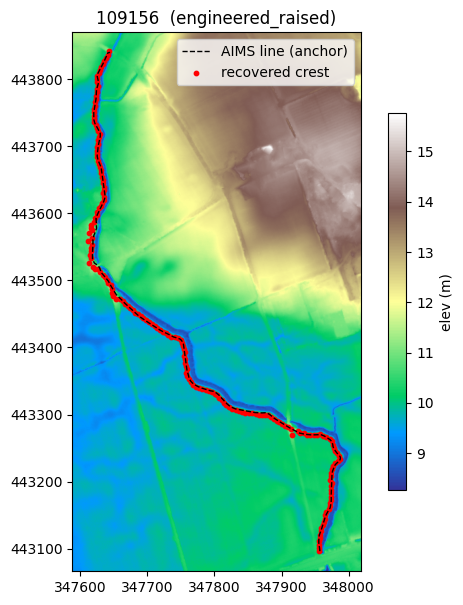

crest_off,crest_z,crest_idx,toe_l,toe_r,li,ri,relheight,width,chainage
f64,f64,i64,f64,f64,i64,i64,f64,f64,f64
2.0,10.78,27,8.769999,10.33,22,29,1.23,7.0,0.0
1.0,10.85,26,8.889999,10.36,20,29,1.225001,9.0,5.0
0.0,10.94,25,8.58,10.94,20,25,1.18,5.0,10.0
0.0,10.99,25,8.48,10.19,18,28,1.655,10.0,15.0
-1.0,10.97,24,8.57,10.97,18,24,1.2,6.0,20.0
…,…,…,…,…,…,…,…,…,…
0.0,10.81,25,10.81,10.07,25,28,0.37,3.0,960.0
0.0,10.84,25,10.84,10.1,25,29,0.37,4.0,965.0
-1.0,10.84,24,8.809999,10.42,19,26,1.225,7.0,970.0


In [35]:

aid = sample["engineered_raised"][0]
geom = assets.set_index("asset_id").loc[aid, "geometry"]
df, sections = plan_view(aid, geom)

df

In [36]:
sections

array([[10.43999958, 10.38000011, 10.52000046, ..., 10.22000027,
        10.21000004, 10.21000004],
       [10.10000038, 10.06000042, 10.01000023, ..., 10.22999954,
        10.22999954, 10.22000027],
       [10.35999966, 10.30000019, 10.27999973, ..., 10.18999958,
        10.19999981, 10.22999954],
       ...,
       [10.36999989, 10.35000038, 10.32999992, ..., 11.        ,
        11.02999973, 11.03999996],
       [10.31999969, 10.31999969, 10.34000015, ..., 11.02000046,
        11.06999969, 11.06999969],
       [10.23999977, 10.22000027, 10.21000004, ..., 10.92000008,
        10.97000027, 11.06999969]], shape=(197, 51))

In [37]:

# def cross_sections(df, sections, n=4):
#     idx = np.linspace(0, len(df) - 1, n).astype(int)
#     fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), sharey=True)

#     for ax, i in zip(axes, idx):
#         r = crest_and_toes(sections[i])
#         ax.plot(OFFSETS, sections[i], lw=1)
#         ax.axvspan(-CREST_BAND, CREST_BAND, color="grey", alpha=0.1)

#         ax.scatter(r["crest_off"], r["crest_z"], c="red", zorder=5, label="crest")
#         ax.scatter(
#             [OFFSETS[r["li"]], OFFSETS[r["ri"]]], 
#             [r["toe_l"], r["toe_r"]],
#             c="green", 
#             zorder=5, 
#             label="toe"
#         )

#         ax.set_title(f"chainage {df['chainage'][i]:.0f} m")
#         ax.set_xlabel("offset (m)")

#     axes[0].set_ylabel("elev (m)")
#     axes[0].legend(fontsize=8)

#     plt.tight_layout()
#     plt.show()

def cross_sections(df, sections, n=4):
    idx = np.linspace(0, len(df) - 1, n).astype(int)
    chain = df["chainage"].to_list()   
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), sharey=True)

    for ax, i in zip(axes, idx):
        i = int(i)

        r = crest_and_toes(sections[i])
        ax.plot(OFFSETS, sections[i], lw=1)
        ax.axvspan(-CREST_BAND, CREST_BAND, color="grey", alpha=0.1)

        ax.scatter(r["crest_off"], r["crest_z"], c="red", zorder=5, label="crest")
        ax.scatter(
            [OFFSETS[r["li"]], OFFSETS[r["ri"]]], 
            [r["toe_l"], r["toe_r"]],
            c="green", 
            zorder=5, 
        label="toe"
        )
        
        ax.set_title(f"chainage {chain[i]:.0f} m")
        ax.set_xlabel("offset (m)")

    axes[0].set_ylabel("elev (m)")
    axes[0].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


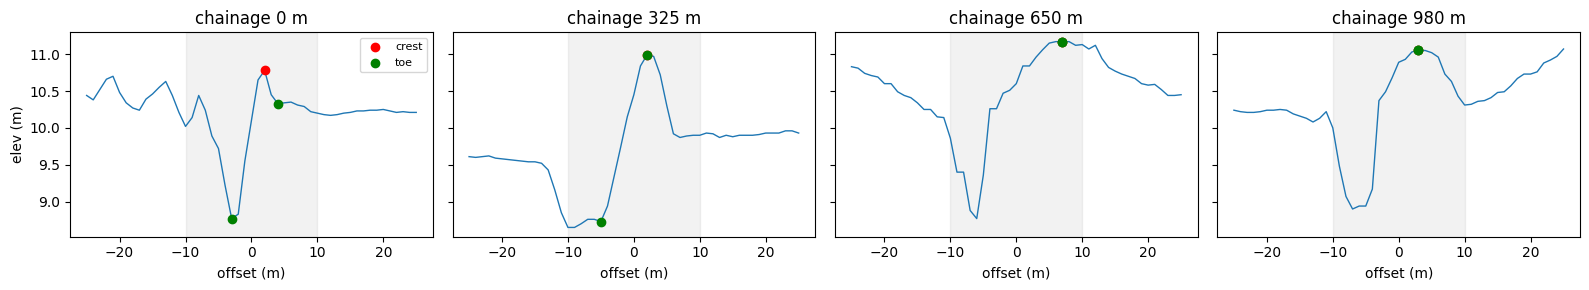

In [38]:

cross_sections(df, sections)


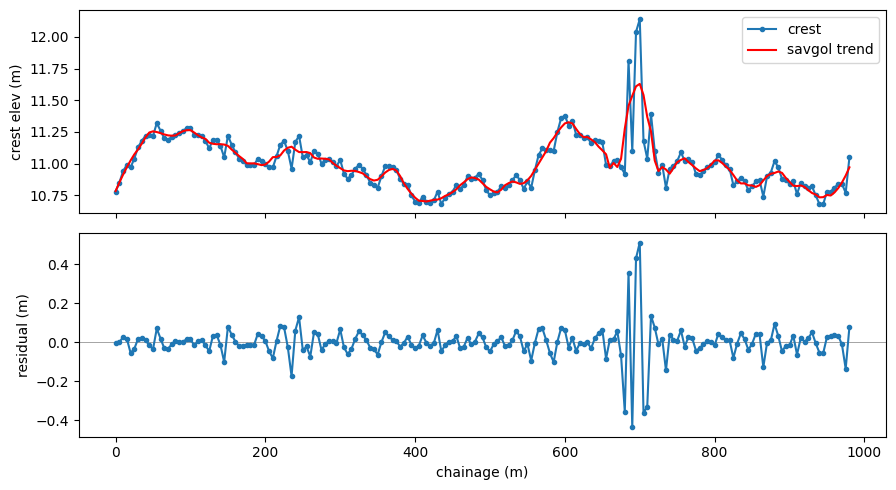

{'resid_std': 0.088, 'ac1': -0.211, 'tv_range': 13.341, 'n_valid': 197, 'frac_valid': 1.0}


In [39]:


def longitudinal(df):
    ch = df["chainage"].to_numpy(); z = df["crest_z"].to_numpy()
    f = resid_features(ch, z)
    if f is None:
        print("too few valid stations"); return
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
    chv = ch[f["ok"]]
    a1.plot(chv, z[f["ok"]], ".-", label="crest"); a1.plot(chv, f["trend"], "r-", label="savgol trend")
    a1.set_ylabel("crest elev (m)"); a1.legend()
    a2.axhline(0, color="grey", lw=0.5); a2.plot(chv, f["resid"], ".-")
    a2.set_ylabel("residual (m)"); a2.set_xlabel("chainage (m)")
    plt.tight_layout(); plt.show()
    print(
        {
            k: round(v, 3) for k, v in f.items()
            if k in ("resid_std", "ac1", "tv_range", "n_valid", "frac_valid")
        }
    )

longitudinal(df)


In [ ]:


rows = []
by_id = assets.set_index("asset_id")

for tier, ids in sample.items():

    for aid in ids:

        df_a, *_ = extract(aid, by_id.loc[aid, "geometry"])
        f = resid_features(df_a["chainage"].to_numpy(), df_a["crest_z"].to_numpy())
        rows.append({
            "asset_id": aid, "tier": tier,
            "sub_type": by_id.loc[aid, "asset_sub_type"],
            "offset_median": float(df_a["crest_off"].abs().median()),
            "relheight_med": float(df_a["relheight"].median()),
            **(
                {k: round(f[k], 3) for k in ("resid_std", "ac1", "tv_range", "frac_valid")}
                if f else {}
            ),
        })
        
pl.DataFrame(rows)

asset_id,tier,sub_type,offset_median,relheight_med,resid_std,ac1,tv_range,frac_valid
i64,str,str,f64,f64,f64,f64,f64,f64
109156,"""engineered_raised""","""Embankment""",1.0,1.03,0.088,-0.211,13.341,1.0
129998,"""engineered_raised""","""Embankment""",1.0,0.0,0.07,-0.162,8.824,1.0
105403,"""engineered_raised""","""Embankment""",0.0,0.577,0.034,-0.306,8.073,1.0
108893,"""engineered_raised""","""Embankment""",3.0,0.0,0.163,-0.123,4.191,1.0
126764,"""wall_like""","""Wall""",8.0,0.0,0.024,0.09,3.779,1.0
…,…,…,…,…,…,…,…,…
112528,"""wall_like""","""Wall""",8.0,0.0,0.083,-0.351,2.96,1.0
123195,"""natural_geomorphic""","""Dunes""",3.0,0.015,0.218,0.211,19.043,1.0
123197,"""natural_geomorphic""","""Dunes""",1.0,0.0,0.12,0.038,12.782,1.0


In [43]:
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=220):
    print(pl.DataFrame(rows))

shape: (12, 9)
┌──────────┬────────────────────┬────────────┬───────────────┬───────────────┬───────────┬────────┬──────────┬────────────┐
│ asset_id ┆ tier               ┆ sub_type   ┆ offset_median ┆ relheight_med ┆ resid_std ┆ ac1    ┆ tv_range ┆ frac_valid │
│ ---      ┆ ---                ┆ ---        ┆ ---           ┆ ---           ┆ ---       ┆ ---    ┆ ---      ┆ ---        │
│ i64      ┆ str                ┆ str        ┆ f64           ┆ f64           ┆ f64       ┆ f64    ┆ f64      ┆ f64        │
╞══════════╪════════════════════╪════════════╪═══════════════╪═══════════════╪═══════════╪════════╪══════════╪════════════╡
│ 109156   ┆ engineered_raised  ┆ Embankment ┆ 1.0           ┆ 1.03          ┆ 0.088     ┆ -0.211 ┆ 13.341   ┆ 1.0        │
│ 129998   ┆ engineered_raised  ┆ Embankment ┆ 1.0           ┆ 0.0           ┆ 0.07      ┆ -0.162 ┆ 8.824    ┆ 1.0        │
│ 105403   ┆ engineered_raised  ┆ Embankment ┆ 0.0           ┆ 0.577         ┆ 0.034     ┆ -0.306 ┆ 8.073    ┆ 1.0   